In [38]:
import hopsworks
import pandas as pd
import numpy as np

# 1. Connect to Hopsworks Feature Store
project = hopsworks.login()
fs = project.get_feature_store(name='aqi_predictor_fsd_featurestore')
fg = fs.get_feature_group('weather_aqi_hourly', version=6)

# 2. Read dataset via Online Store
df = fg.read(online=True)

# 3. Sort chronologically (Online store returns unsorted records)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['time'].min()} to {df['time'].max()}")

2026-08-27 02:35:37,783 INFO: Closing external client and cleaning up certificates.


2026-08-27 02:35:37,793 INFO: Connection closed.
2026-08-27 02:35:37,797 INFO: Initializing external client
2026-08-27 02:35:37,798 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-08-27 02:35:42,336 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/42119
Dataset shape: (17592, 45)
Date range: 2024-08-24 00:00:00 to 2026-08-26 23:00:00


In [39]:
df.tail(20)

,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,wind_direction_10m,pm2_5,pm10,nitrogen_dioxide,ozone,...,us_aqi_roll_mean_24h,us_aqi_roll_std_24h,us_aqi_roll_min_24h,us_aqi_roll_max_24h,aqi_change_rate_1h,aqi_change_rate_24h,pm25_pm10_ratio,target_aqi_24h,target_aqi_48h,target_aqi_72h
17572,2026-08-26 04:00:00,30.1,76,981.1,4.6,149,84.1,99.9,52.6,14.0,...,166.125000,4.711803,162.0,181.0,-1.0,2.0,0.841842,NaN,NaN,NaN
17573,2026-08-26 05:00:00,30.4,76,981.1,4.8,115,85.0,102.0,47.6,23.0,...,166.125000,4.711803,162.0,181.0,-1.0,0.0,0.833333,NaN,NaN,NaN
17574,2026-08-26 06:00:00,29.6,79,981.2,5.2,119,80.6,97.6,43.0,45.0,...,166.041667,4.786568,161.0,181.0,-1.0,-2.0,0.825820,NaN,NaN,NaN
17575,2026-08-26 07:00:00,30.2,77,981.7,5.8,150,78.9,93.6,36.3,77.0,...,165.916667,4.880455,161.0,181.0,0.0,-3.0,0.842949,NaN,NaN,NaN
17576,2026-08-26 08:00:00,31.9,68,982.1,5.4,178,70.8,90.6,28.9,107.0,...,165.708333,5.025839,160.0,181.0,-1.0,-5.0,0.781457,NaN,NaN,NaN
17577,2026-08-26 09:00:00,34.0,57,982.2,5.5,193,56.6,85.2,20.2,132.0,...,165.541667,5.115868,160.0,181.0,1.0,-4.0,0.664319,NaN,NaN,NaN
17578,2026-08-26 10:00:00,35.5,48,982.3,5.2,202,47.7,81.0,10.9,156.0,...,165.416667,5.191269,160.0,181.0,0.0,-3.0,0.588889,NaN,NaN,NaN
17579,2026-08-26 11:00:00,36.3,45,982.4,4.4,201,43.2,76.8,4.3,173.0,...,165.333333,5.230900,160.0,181.0,1.0,-2.0,0.562500,NaN,NaN,NaN
17580,2026-08-26 12:00:00,36.6,45,982.0,3.9,208,41.1,74.3,2.2,182.0,...,165.250000,5.268858,160.0,181.0,0.0,-2.0,0.553163,NaN,NaN,NaN
17581,2026-08-26 13:00:00,36.9,44,981.3,3.1,216,39.9,72.4,2.7,186.0,...,165.166667,5.305179,160.0,181.0,0.0,-2.0,0.551105,NaN,NaN,NaN


### Checking the data in feature store that is it ready for inference and model training

In [41]:
import hopsworks
import numpy as np
import pandas as pd

# 1. Connect to Hopsworks Feature Store
project = hopsworks.login()
fs = project.get_feature_store(name="aqi_predictor_fsd_featurestore")
fg = fs.get_feature_group("weather_aqi_hourly", version=6)

# 2. Read dataset via Online Store
df = fg.read(online=True)

# 3. Sort chronologically (Online store returns unsorted records)
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

# Define all target columns
target_cols = ["target_aqi_24h", "target_aqi_48h", "target_aqi_72h"]

# Filter 1: Training Dataset (All historical rows where ALL target values are present)
train_df = df.dropna(subset=target_cols).reset_index(drop=True)

# Filter 2: Real-time / Inference Row (The absolute latest row up to current hour)
latest_row = df.tail(1)

# Display Summary
print(f"Total rows in Online Store: {len(df)}")
print(f"Date range: {df['time'].min()} to {df['time'].max()}\n")

print("--- TRAINING DATASET STATUS ---")
print(f"Training set shape: {train_df.shape}")
print(f"Trainable date range: {train_df['time'].min()} to {train_df['time'].max()}")
print(
    f"Missing targets in training subset: {train_df[target_cols].isna().sum().to_dict()}\n"
)

print("--- LATEST INFERENCE ROW (CURRENT HOUR) ---")
print(f"Timestamp: {latest_row['time'].values[0]}")
print(f"Current AQI: {latest_row['us_aqi'].values[0]}")
print(f"Target 24h: {latest_row['target_aqi_24h'].values[0]}")
print(f"Target 48h: {latest_row['target_aqi_48h'].values[0]}")
print(f"Target 72h: {latest_row['target_aqi_72h'].values[0]}")

2026-08-27 02:41:11,147 INFO: Closing external client and cleaning up certificates.
2026-08-27 02:41:11,150 INFO: Connection closed.
2026-08-27 02:41:11,152 INFO: Initializing external client
2026-08-27 02:41:11,153 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-08-27 02:41:14,129 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/42119
Total rows in Online Store: 17592
Date range: 2024-08-24 00:00:00 to 2026-08-26 23:00:00

--- TRAINING DATASET STATUS ---
Training set shape: (17520, 45)
Trainable date range: 2024-08-24 00:00:00 to 2026-08-23 23:00:00
Missing targets in training subset: {'target_aqi_24h': 0, 'target_aqi_48h': 0, 'target_aqi_72h': 0}

--- LATEST INFERENCE ROW (CURRENT HOUR) ---
Timestamp: 2026-08-26T23:00:00.000000000
Current AQI: 161
Target 24h: nan
Target 48h: nan
Target 72h: nan


# Data Preprocessing

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17592 entries, 0 to 17591
Data columns (total 45 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   time                  17592 non-null  datetime64[ns]
 1   temperature_2m        17592 non-null  float64       
 2   relative_humidity_2m  17592 non-null  int64         
 3   surface_pressure      17592 non-null  float64       
 4   wind_speed_10m        17592 non-null  float64       
 5   wind_direction_10m    17592 non-null  int64         
 6   pm2_5                 17592 non-null  float64       
 7   pm10                  17592 non-null  float64       
 8   nitrogen_dioxide      17592 non-null  float64       
 9   ozone                 17592 non-null  float64       
 10  us_aqi                17592 non-null  int64         
 11  city                  17592 non-null  object        
 12  wind_u                17592 non-null  float64       
 13  wind_v          

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17592 entries, 0 to 17591
Data columns (total 45 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   time                  17592 non-null  datetime64[ns]
 1   temperature_2m        17592 non-null  float64       
 2   relative_humidity_2m  17592 non-null  int64         
 3   surface_pressure      17592 non-null  float64       
 4   wind_speed_10m        17592 non-null  float64       
 5   wind_direction_10m    17592 non-null  int64         
 6   pm2_5                 17592 non-null  float64       
 7   pm10                  17592 non-null  float64       
 8   nitrogen_dioxide      17592 non-null  float64       
 9   ozone                 17592 non-null  float64       
 10  us_aqi                17592 non-null  int64         
 11  city                  17592 non-null  object        
 12  wind_u                17592 non-null  float64       
 13  wind_v          

In [44]:
df.isna().sum().sum()

np.int64(144)

In [65]:
df = df.dropna()
df = df.drop_duplicates()

In [66]:
import pandas as pd

# Select only numeric columns (int, float)
numeric_df = df.select_dtypes(include=['number'])
# Custom aggregate on numeric columns
numeric_metrics = numeric_df.agg(['min', 'max', 'std', 'mean', 'nunique'])
print(numeric_metrics)

         temperature_2m  relative_humidity_2m  surface_pressure  \
min            2.400000              4.000000        969.400000   
max           46.900000            100.000000       1005.500000   
std            8.534636             22.410273          7.033900   
mean          25.362580             58.549886        986.337511   
nunique      429.000000             97.000000        338.000000   

         wind_speed_10m  wind_direction_10m        pm2_5         pm10  \
min            0.000000            1.000000     3.400000     3.400000   
max           38.400000          360.000000   486.200000   804.700000   
std            3.378087           97.525198    66.834766    80.716307   
mean           6.449743          162.840982    82.917677   110.714572   
nunique      227.000000          360.000000  1170.000000  1247.000000   

         nitrogen_dioxide       ozone      us_aqi  ...  us_aqi_roll_mean_24h  \
min              0.000000    0.000000   69.000000  ...             72.541667  

In [67]:
import pandas as pd

target_cols = ["target_aqi_24h", "target_aqi_48h", "target_aqi_72h"]
metadata_cols = ["time", "city"]
feature_cols = [c for c in df.columns if c not in target_cols + metadata_cols]

X = df[feature_cols]
y = df[target_cols]

# 3. Calculate Index Cutoffs (80% Train, 10% Val, 10% Test)
n = len(df)
train_end = int(n * 0.80)
val_end = int(n * 0.90)

# Maximum horizon gap (72 hours) to avoid target overlap
GAP = 72  

# Train set
X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

# Validation set (skip GAP rows after train_end)
X_val = X.iloc[train_end + GAP : val_end]
y_val = y.iloc[train_end + GAP : val_end]

# Test set (skip GAP rows after val_end)
X_test = X.iloc[val_end + GAP :]
y_test = y.iloc[val_end + GAP :]

print(f"Train Range: {df['time'].iloc[0]} to {df['time'].iloc[train_end-1]}")
print(f"Val Range:   {df['time'].iloc[train_end+GAP]} to {df['time'].iloc[val_end-1]}")
print(f"Test Range:  {df['time'].iloc[val_end+GAP]} to {df['time'].iloc[-1]}")

Train Range: 2024-08-24 00:00:00 to 2026-03-30 23:00:00
Val Range:   2026-04-03 00:00:00 to 2026-06-11 23:00:00
Test Range:  2026-06-15 00:00:00 to 2026-08-23 23:00:00


Computing Spearman Correlation on TRAINING DATA ONLY (2024-08-24 00:00:00 to 2026-03-30 23:00:00)...

--- TOP FEATURES CORRELATED WITH TARGETS ---

Top 10 features for target_aqi_24h:
us_aqi                  0.823351
us_aqi_lag_1h           0.812485
pm2_5_roll_mean_24h     0.806567
us_aqi_roll_mean_24h    0.756132
us_aqi_roll_min_24h     0.750329
us_aqi_roll_max_24h     0.726018
pm2_5_roll_mean_6h      0.718169
us_aqi_lag_24h          0.714865
pm2_5                   0.713113
pm2_5_roll_std_24h      0.702076
pm2_5_lag_1h            0.693405
us_aqi_lag_48h          0.674767
cos_month               0.666454
us_aqi_lag_72h          0.656905
pm10                    0.615332
surface_pressure        0.614926
pm2_5_lag_24h           0.574380
temperature_2m          0.520951
pm25_pm10_ratio         0.465349
wind_speed_10m          0.425259
Name: target_aqi_24h, dtype: float64

Top 10 features for target_aqi_48h:
us_aqi                  0.714339
us_aqi_lag_1h           0.708600
pm2_5_roll_mean_

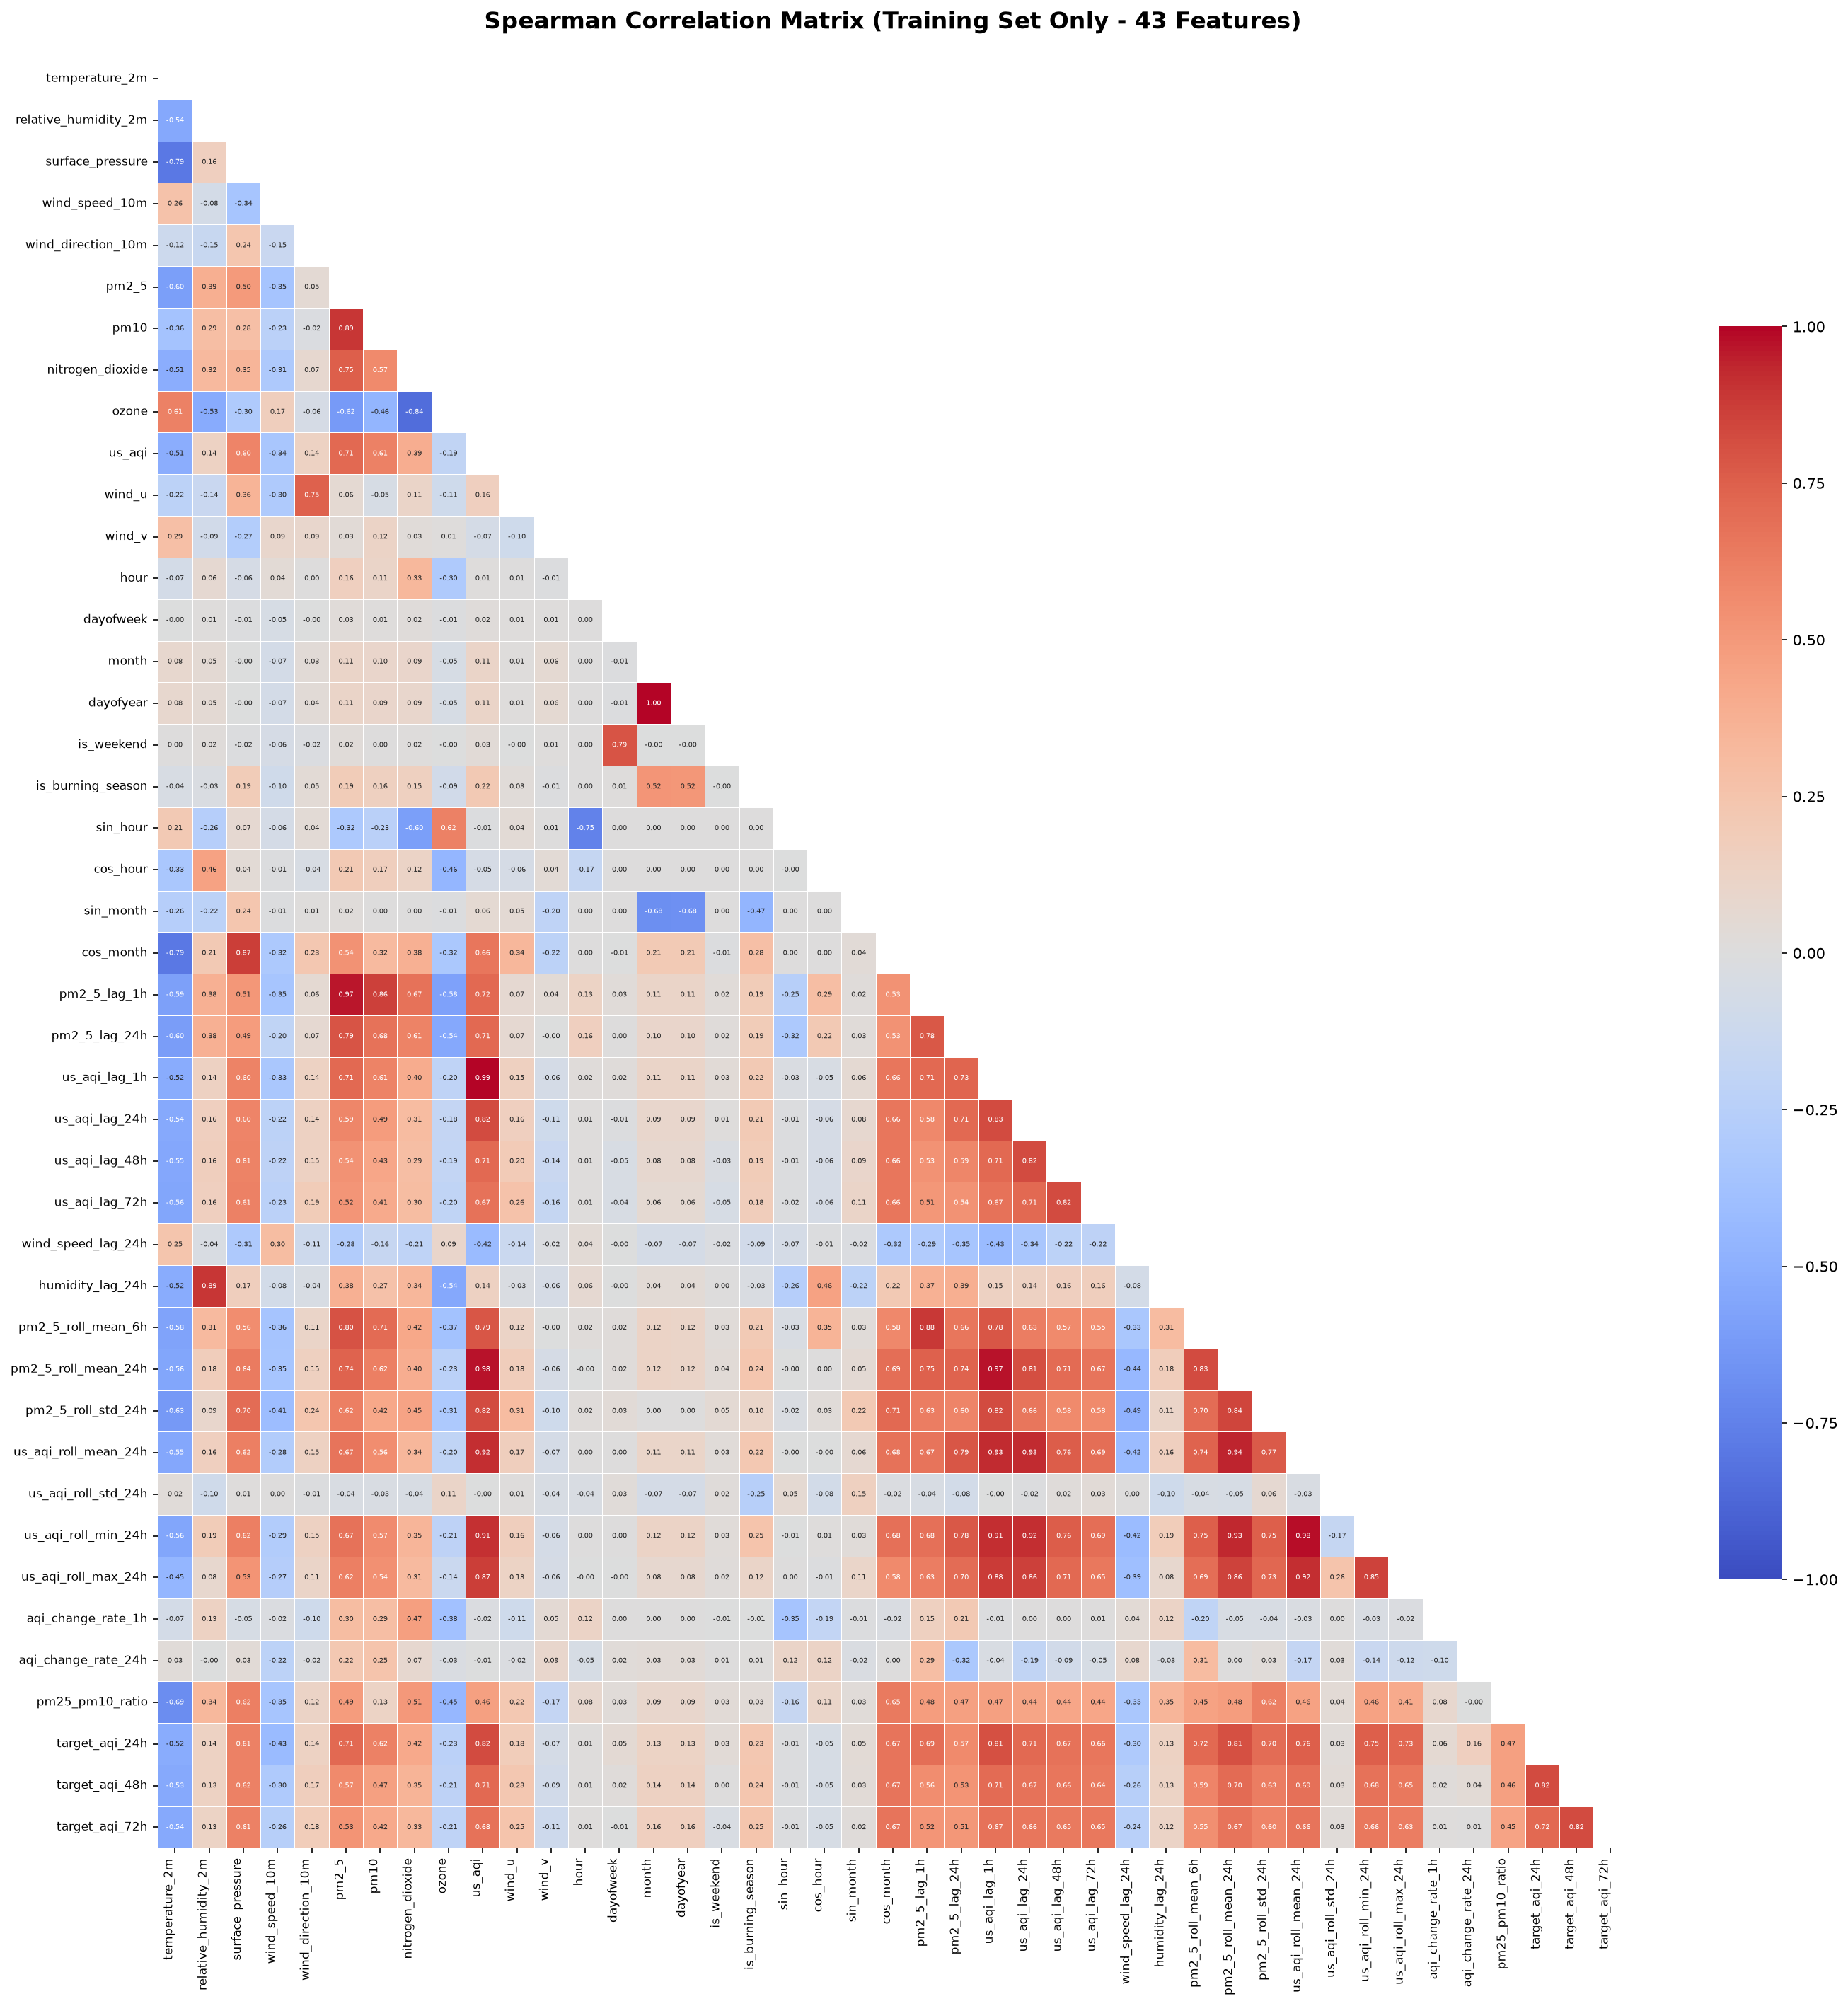

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

n= len(df)
train_end = int(n * 0.80)

# Isolate training set exclusively to compute statistics/correlations
train_df = df.iloc[:train_end].copy()

# Select numeric features for training
numeric_train_df = train_df.select_dtypes(include=[np.number])

print(
    f"Computing Spearman Correlation on TRAINING DATA ONLY ({train_df['time'].iloc[0]} to {train_df['time'].iloc[-1]})..."
)

# 4. Compute Spearman Rank Correlation Matrix
corr_matrix = numeric_train_df.corr(method="spearman")

# 5. Extract Feature Correlation with Target Horizons
print("\n--- TOP FEATURES CORRELATED WITH TARGETS ---")
for target in target_cols:
    if target in corr_matrix.columns:
        top_features = (
            corr_matrix[target]
            .drop(labels=target_cols, errors="ignore")
            .abs()
            .sort_values(ascending=False)
            .head(20)
        )
        print(f"\nTop 10 features for {target}:")
        print(top_features)

# 6. Plot High-Resolution Correlation Heatmap
num_features = numeric_train_df.shape[1]
fig_size = max(18, int(num_features * 0.45))

plt.figure(figsize=(fig_size, fig_size), dpi=150)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    annot_kws={"size": max(5, 140 // num_features)},
    cbar_kws={"shrink": 0.7},
)

plt.title(
    f"Spearman Correlation Matrix (Training Set Only - {num_features} Features)",
    fontsize=16,
    pad=20,
    weight="bold",
)
plt.xticks(rotation=90, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()

plt.savefig("train_feature_correlation_matrix_v1.png", dpi=300, bbox_inches="tight")
print("Heatmap saved as 'train_feature_correlation_matrix.png'")
plt.show()

In [69]:
y_train.head()

,target_aqi_24h,target_aqi_48h,target_aqi_72h
0,150.0,158.0,153.0
1,151.0,158.0,151.0
2,151.0,158.0,150.0
3,151.0,159.0,146.0
4,152.0,159.0,143.0


In [70]:
FINAL_FEATURES = [
    # --- Current Primary AQI State ---
    "us_aqi",
    "pm25_pm10_ratio",
    
    # --- Diurnal Lags (24h Cycles) ---
    "us_aqi_lag_24h",
    "us_aqi_lag_48h",
    "us_aqi_lag_72h",
    
    # --- Aggregated Rolling Context ---
    "us_aqi_roll_mean_24h",
    "us_aqi_roll_min_24h",
    "us_aqi_roll_max_24h",
    "us_aqi_roll_std_24h",
    
    # --- Meteorological Signals ---
    "temperature_2m",
    "surface_pressure",
    "wind_speed_10m",
    "wind_u",
    "wind_v",
    
    # --- Cyclical Time Encodings ---
    "cos_month",
    "sin_month",
    "cos_hour",
    "sin_hour",
    "is_weekend"
]

In [71]:
x_train_filtered = X_train[FINAL_FEATURES]
x_test_filtered = X_test[FINAL_FEATURES]

In [72]:
x_train_filtered.agg(['min','mean','median','max','std']).to_json()

'{"us_aqi":{"min":69.0,"mean":172.1865011416,"median":160.0,"max":437.0,"std":58.1114461208},"pm25_pm10_ratio":{"min":0.1816021224,"mean":0.7903940489,"median":0.8764107322,"max":0.99999997,"std":0.207807066},"us_aqi_lag_24h":{"min":69.0,"mean":172.2437214612,"median":160.0,"max":437.0,"std":58.0599868464},"us_aqi_lag_48h":{"min":69.0,"mean":172.3065068493,"median":160.0,"max":437.0,"std":57.9842347259},"us_aqi_lag_72h":{"min":69.0,"mean":172.2258133562,"median":160.0,"max":437.0,"std":58.0502410746},"us_aqi_roll_mean_24h":{"min":72.5416666667,"mean":172.222757325,"median":159.125,"max":362.0416666667,"std":56.3091988409},"us_aqi_roll_min_24h":{"min":69.0,"mean":156.5057791096,"median":152.0,"max":346.0,"std":53.9948211282},"us_aqi_roll_max_24h":{"min":75.0,"mean":191.7301655251,"median":176.0,"max":437.0,"std":58.4648279154},"us_aqi_roll_std_24h":{"min":0.5036101552,"mean":11.1559869154,"median":8.8667163583,"max":114.8723220028,"std":9.325362348},"temperature_2m":{"min":2.4,"mean":23

## Scaling the data for distance based algorithums like Linear Regression

### Linear Regression

In [73]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()

x_train_scaled = robust_scaler.fit_transform(x_train_filtered)

In [74]:
x_train_scaled[:5]

array([[-1.96428571e-01, -7.54204081e-01, -1.07142857e+00,
        -9.28571429e-01, -1.10714286e+00, -5.83409969e-01,
        -9.15254237e-01,  5.66037736e-02,  1.85566897e+00,
         1.42857143e-01, -5.00000000e-01,  3.61363636e+00,
        -2.05718478e+00, -2.50184183e+00, -7.32050808e-01,
        -5.00000000e-01,  7.07106781e-01, -4.32978028e-17,
         1.00000000e+00],
       [-1.78571429e-01, -7.21673722e-01, -1.08928571e+00,
        -9.10714286e-01, -1.12500000e+00, -5.47360677e-01,
        -9.15254237e-01,  5.66037736e-02,  1.83598698e+00,
         2.63157895e-01, -5.44642857e-01,  1.06818182e+00,
        -1.26123789e+00,  3.12977998e-01, -7.32050808e-01,
        -5.00000000e-01,  6.83012702e-01,  1.83012702e-01,
         1.00000000e+00],
       [-1.60714286e-01, -7.29067694e-01, -1.10714286e+00,
        -8.92857143e-01, -1.12500000e+00, -5.09839985e-01,
        -9.15254237e-01,  5.66037736e-02,  1.79872273e+00,
         2.93233083e-01, -4.46428571e-01,  9.31818182e-01,
    

In [75]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
y_train_24h = y_train['target_aqi_24h']
model.fit(X=x_train_scaled,y=y_train_24h)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](19,)","[45.7 ,-5.42,11.39,...,-4.39, 0.53,-1.01]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,164.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,19
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(19)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](19,)","[307.34,125.18,106.37,..., 17.43, 9.91, 6.47]"


In [76]:
x_test_scaled = robust_scaler.transform(x_test_filtered)
y_pred = model.predict(x_test_scaled)

In [77]:
y_test.head

<bound method NDFrame.head of        target_aqi_24h  target_aqi_48h  target_aqi_72h
15840           137.0           151.0           164.0
15841           139.0           152.0           163.0
15842           141.0           152.0           162.0
15843           142.0           153.0           161.0
15844           143.0           153.0           160.0
...               ...             ...             ...
17515           161.0           178.0           164.0
17516           150.0           166.0           161.0
17517           151.0           166.0           161.0
17518           152.0           167.0           161.0
17519           154.0           166.0           161.0

[1680 rows x 3 columns]>

In [78]:
from sklearn.metrics import mean_squared_error,root_mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score


results_linear_24h = []
y_test_24h = y_test['target_aqi_24h']
mse = mean_squared_error(y_test_24h, y_pred)
rmse = root_mean_squared_error(y_test_24h, y_pred)
mae = mean_absolute_error(y_test_24h, y_pred)
mape = mean_absolute_percentage_error(y_test_24h, y_pred)
r2 = r2_score(y_test_24h, y_pred)

results_linear_24h.append({
    "MSE": mse,
    "RMSE": rmse,
    "MAE": mae,
    "MAPE": mape,
    "R2 Score": r2
})

print(results_linear_24h)

[{'MSE': 466.59431603983836, 'RMSE': 21.60079433816818, 'MAE': 16.478991438549794, 'MAPE': 0.11058269926901994, 'R2 Score': 0.11152107246538623}]


### Decision Tree

In [79]:
from sklearn.tree import DecisionTreeRegressor

decision_tree_model = DecisionTreeRegressor(max_depth=5, min_samples_leaf=20, random_state=42)
decision_tree_model.fit(X=x_train_filtered,y=y_train_24h)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes ma

In [80]:
y_pred_decision_tree = decision_tree_model.predict(x_test_filtered)

results_decision_tree_24h = []
mse = mean_squared_error(y_test_24h, y_pred_decision_tree)
rmse = root_mean_squared_error(y_test_24h, y_pred_decision_tree)
mae = mean_absolute_error(y_test_24h, y_pred_decision_tree)
mape = mean_absolute_percentage_error(y_test_24h, y_pred_decision_tree)
r2 = r2_score(y_test_24h, y_pred_decision_tree)

results_decision_tree_24h.append({
    "MSE": mse,
    "RMSE": rmse,
    "MAE": mae,
    "MAPE": mape,
    "R2 Score": r2
})

print(results_decision_tree_24h)

[{'MSE': 528.8159268615588, 'RMSE': 22.99599806187065, 'MAE': 18.06585738203195, 'MAPE': 0.12456834069548017, 'R2 Score': -0.006959989459161875}]


In [81]:
print("Train R2:", r2_score(y_train_24h, decision_tree_model.predict(x_train_filtered)))

Train R2: 0.7441047596009089


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# ── 1. Persistence baseline: naive "tomorrow's AQI = today's AQI" ──
baseline_pred = x_test_filtered['us_aqi']
print("=== Persistence Baseline (24h) ===")
print("R2: ", r2_score(y_test_24h, baseline_pred))
print("MAE:", mean_absolute_error(y_test_24h, baseline_pred))

# ── 2. Distribution shift check: train vs test feature stats ──
print("\n=== Train vs Test feature stats (us_aqi) ===")
print("Train:", x_train_filtered['us_aqi'].agg(['min', 'mean', 'median', 'max', 'std']).to_dict())
print("Test: ", x_test_filtered['us_aqi'].agg(['min', 'mean', 'median', 'max', 'std']).to_dict())

print("\n=== Train vs Test target stats (target_aqi_24h) ===")
print("Train:", y_train_24h.agg(['min', 'mean', 'median', 'max', 'std']).to_dict())
print("Test: ", y_test_24h.agg(['min', 'mean', 'median', 'max', 'std']).to_dict())

# ── 3. Constrained decision tree, train vs test R2 side by side ──
tree_model = DecisionTreeRegressor(max_depth=5, min_samples_leaf=20, random_state=42)
tree_model.fit(X=x_train_filtered, y=y_train_24h)

train_pred = tree_model.predict(x_train_filtered)
test_pred = tree_model.predict(x_test_filtered)

print("\n=== Constrained Tree (24h) ===")
print("Train R2:", r2_score(y_train_24h, train_pred))
print("Test R2: ", r2_score(y_test_24h, test_pred))
print("Test MAE:", mean_absolute_error(y_test_24h, test_pred))

=== Persistence Baseline (24h) ===
R2:  -0.07139517616134805
MAE: 17.689285714285713

=== Train vs Test feature stats (us_aqi) ===
Train: {'min': 69.0, 'mean': 172.1865011415525, 'median': 160.0, 'max': 437.0, 'std': 58.1114461207713}
Test:  {'min': 82.0, 'mean': 151.0767857142857, 'median': 154.0, 'max': 241.0, 'std': 23.22301817901748}

=== Train vs Test target stats (target_aqi_24h) ===
Train: {'min': 69.0, 'mean': 172.12878139269407, 'median': 160.0, 'max': 437.0, 'std': 58.15293512530489}
Test:  {'min': 82.0, 'mean': 151.41607142857143, 'median': 154.0, 'max': 241.0, 'std': 22.923210836171364}

=== Constrained Tree (24h) ===
Train R2: 0.7441047596009089
Test R2:  -0.006959989459161875
Test MAE: 18.06585738203195


In [93]:




print(f"Train: {y_train_24h.agg(['mean','median'])}, \n Test: {y_test_24h.agg(['mean','median'])}")

Train: mean      172.128781
median    160.000000
Name: target_aqi_24h, dtype: float64, 
 Test: mean      151.416071
median    154.000000
Name: target_aqi_24h, dtype: float64


In [90]:
tree_model.predict(x_test_filtered.head(1))

array([142.64504505])

In [91]:
y_test_24h.head(1)

15840    137.0
Name: target_aqi_24h, dtype: float64

In [94]:
# pip install xgboost --break-system-packages   (if not already installed)
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

# ── XGBoost needs no scaling — tree splits are invariant to monotonic transforms ──
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=4,              # shallower than default — guards against the overfitting you saw with the plain tree
    learning_rate=0.05,
    subsample=0.8,            # row sampling — reduces overfitting to any one period
    colsample_bytree=0.8,     # feature sampling — same reason
    min_child_weight=5,       # requires more samples per leaf, similar spirit to min_samples_leaf
    reg_alpha=0.1,            # L1 regularization
    reg_lambda=1.0,           # L2 regularization
    random_state=42,
    early_stopping_rounds=30,
    eval_metric="mae",
)

xgb_model.fit(
    x_train_filtered, y_train_24h,
    eval_set=[(x_test_filtered, y_test_24h)],
    verbose=False,
)

train_pred = xgb_model.predict(x_train_filtered)
test_pred = xgb_model.predict(x_test_filtered)

print("=== XGBoost (24h) ===")
print("Train R2:", r2_score(y_train_24h, train_pred))
print("Test R2: ", r2_score(y_test_24h, test_pred))
print("Test MAE:", mean_absolute_error(y_test_24h, test_pred))
print("Test RMSE:", root_mean_squared_error(y_test_24h, test_pred))
print("Best iteration:", xgb_model.best_iteration)  # how many trees it actually used before early stopping kicked in

# ── Feature importance — tells you which features are actually earning their place ──
importance = pd.Series(xgb_model.feature_importances_, index=x_train_filtered.columns).sort_values(ascending=False)
print("\n=== Feature Importance ===")
print(importance)

=== XGBoost (24h) ===
Train R2: 0.686194969253697
Test R2:  0.23246939575457237
Test MAE: 14.487597165788923
Test RMSE: 20.076777536089832
Best iteration: 23

=== Feature Importance ===
us_aqi                  0.381409
cos_month               0.182969
us_aqi_roll_max_24h     0.118351
us_aqi_roll_min_24h     0.037564
pm25_pm10_ratio         0.028250
wind_u                  0.028001
us_aqi_lag_48h          0.025008
us_aqi_lag_72h          0.023962
wind_v                  0.023462
sin_month               0.022210
wind_speed_10m          0.021811
surface_pressure        0.021745
us_aqi_roll_std_24h     0.020904
us_aqi_lag_24h          0.019218
us_aqi_roll_mean_24h    0.012639
temperature_2m          0.011933
sin_hour                0.008257
is_weekend              0.007584
cos_hour                0.004725
dtype: float32


In [95]:
tscv = TimeSeriesSplit(n_splits=5, gap=72)  # gap=72 preserves your leakage protection across folds

fold_scores = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(x_train_filtered)):
    X_tr, X_te = x_train_filtered.iloc[train_idx], x_train_filtered.iloc[test_idx]
    y_tr, y_te = y_train_24h.iloc[train_idx], y_train_24h.iloc[test_idx]

    model = XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        random_state=42,
    )
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    r2 = r2_score(y_te, pred)
    mae = mean_absolute_error(y_te, pred)
    fold_scores.append({"fold": fold, "R2": r2, "MAE": mae, "test_std": y_te.std()})
    print(f"Fold {fold}: R2={r2:.3f}  MAE={mae:.2f}  test_std={y_te.std():.2f}")

results_df = pd.DataFrame(fold_scores)
print("\nMean R2:", results_df["R2"].mean(), "  Mean MAE:", results_df["MAE"].mean())

Fold 0: R2=0.583  MAE=31.46  test_std=67.66
Fold 1: R2=-0.010  MAE=24.34  test_std=36.20
Fold 2: R2=0.119  MAE=22.62  test_std=30.43
Fold 3: R2=0.550  MAE=25.15  test_std=48.29
Fold 4: R2=0.747  MAE=24.24  test_std=64.32

Mean R2: 0.39785667880089437   Mean MAE: 25.563897437265474


In [96]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "reg_alpha": [0, 0.1, 0.5, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=40,
    scoring="neg_mean_absolute_error",   # optimize MAE, not R2, given the variance issue above
    cv=TimeSeriesSplit(n_splits=5, gap=72),
    random_state=42,
    n_jobs=-1,
)
search.fit(x_train_filtered, y_train_24h)

print("Best params:", search.best_params_)
print("Best CV MAE:", -search.best_score_)

best_model = search.best_estimator_
test_pred = best_model.predict(x_test_filtered)
print("Final Test MAE:", mean_absolute_error(y_test_24h, test_pred))
print("Final Test R2:", r2_score(y_test_24h, test_pred))

Best params: {'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
Best CV MAE: 24.63675632150206
Final Test MAE: 15.98772923151652
Final Test R2: 0.22430798621451598
